In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.DataFrame({
    'h': [150, 160, 170, 185, 190],
    'w': [50, 58, 70, 80, 90]
})
df

,h,w
0,150,50
1,160,58
2,170,70
3,185,80
4,190,90


In [3]:
m = df.mean()
s = df.std()

print("Mean values:\n", m)
print("\nStandard Deviation:\n", s)


Mean values:
 h    171.0
w     69.6
dtype: float64

Standard Deviation:
 h    16.733201
w    16.149303
dtype: float64


In [4]:
z = (df - m) / s
z.round(2)

,h,w
0,-1.25,-1.21
1,-0.66,-0.72
2,-0.06,0.02
3,0.84,0.64
4,1.14,1.26


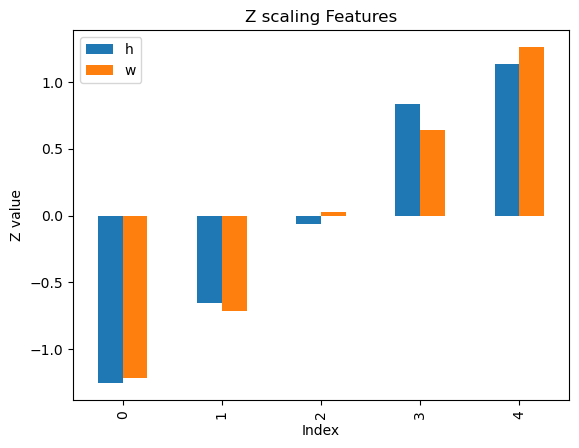

In [5]:
z.plot(kind='bar')
plt.title("Z scaling Features")
plt.xlabel("Index")
plt.ylabel("Z value")
plt.show()

In [6]:
df = pd.DataFrame({
    'h': [150, 175, 170, 180, 190],
    'w': [50, 60, 70, 180, 90]
})
df

,h,w
0,150,50
1,175,60
2,170,70
3,180,180
4,190,90


In [7]:
mn = df.min()
mx = df.max()
rg = mx-mn
print("Min values:\n", mn)
print("\nMax values:\n", mx)
print("\nRange:\n", rg)

Min values:
 h    150
w     50
dtype: int64

Max values:
 h    190
w    180
dtype: int64

Range:
 h     40
w    130
dtype: int64


In [8]:
ss = df - mn
ss.head()

,h,w
0,0,0
1,25,10
2,20,20
3,30,130
4,40,40


In [9]:
mm = ss / rg
mm.head()

,h,w
0,0.000,0.000000
1,0.625,0.076923
2,0.500,0.153846
3,0.750,1.000000
4,1.000,0.307692


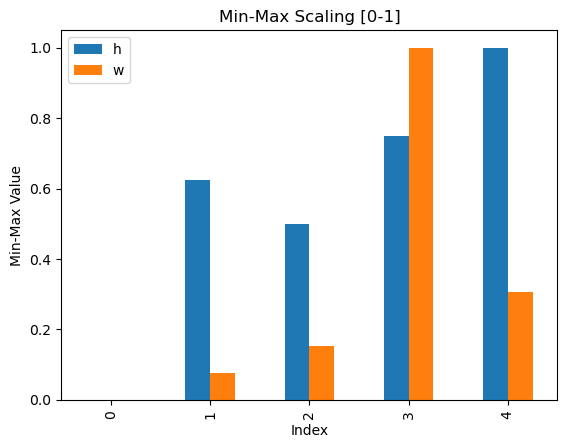

In [10]:
mm.plot(kind='bar')
plt.title("Min-Max Scaling [0-1]")
plt.xlabel("Index")
plt.ylabel("Min-Max Value")
plt.show()

In [14]:
df = pd.DataFrame({
    'h': [150, 160, 170, 180, 300],
    'w': [50, 60, 70, 80, 200]
})

df

,h,w
0,150,50
1,160,60
2,170,70
3,180,80
4,300,200


In [15]:
md = df.median()
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
md, q1, q3, iqr

(h    170.0
 w     70.0
 dtype: float64,
 h    160.0
 w     60.0
 Name: 0.25, dtype: float64,
 h    180.0
 w     80.0
 Name: 0.75, dtype: float64,
 h    20.0
 w    20.0
 dtype: float64)

In [16]:
ct = df -md
ct

,h,w
0,-20.0,-20.0
1,-10.0,-10.0
2,0.0,0.0
3,10.0,10.0
4,130.0,130.0


In [17]:
rb = ct/iqr
rb.round(2)

,h,w
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,6.5,6.5


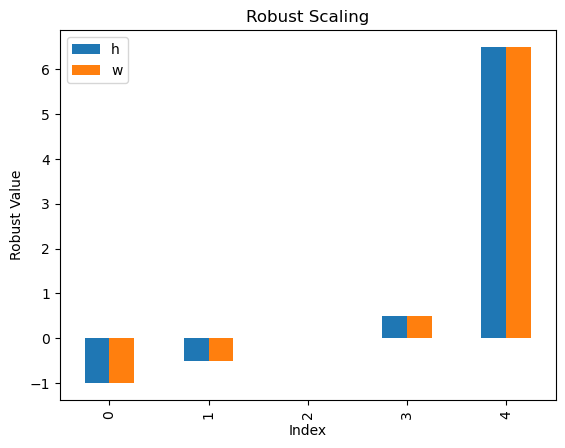

In [18]:
rb.plot(kind='bar')
plt.title("Robust Scaling")
plt.xlabel("Index")
plt.ylabel("Robust Value")
plt.show()

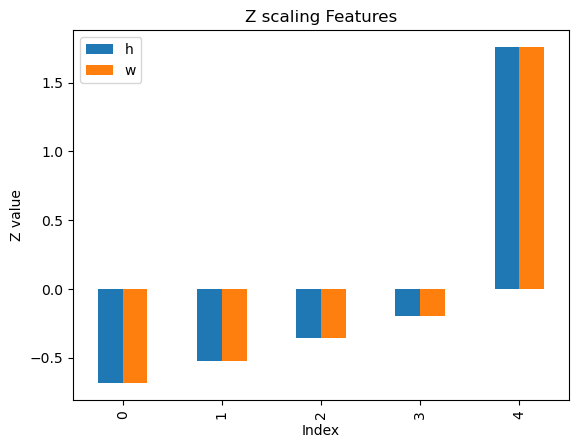

In [19]:
# Standardization (Z-Score Normalization)
m = df.mean()
s = df.std()
z= (df-m)/s
z.plot(kind='bar')
plt.title("Z scaling Features")
plt.xlabel("Index")
plt.ylabel("Z value")
plt.show()


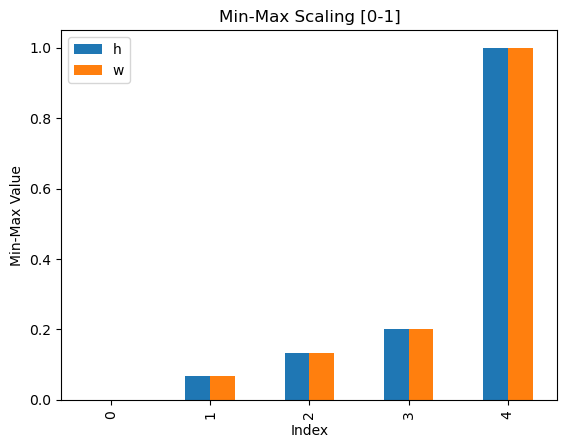

In [20]:
# Min-Max Scaling [0-1]
mn = df.min()
mx = df.max()
rg = mx-mn
ss = df - mn
mm = ss / rg
mm.plot(kind='bar')
plt.title("Min-Max Scaling [0-1]")
plt.xlabel("Index")
plt.ylabel("Min-Max Value")
plt.show()

In [21]:
df = pd.DataFrame({
    "id" : [1,2,3,4],
    "color" : ["red", "blue", "green", "yellow"],
    "size" : ["Small", "Medium", "Large", "Medium"],
    "price" : [10,12,15,11]
})
df

,id,color,size,price
0,1,red,Small,10
1,2,blue,Medium,12
2,3,green,Large,15
3,4,yellow,Medium,11


In [23]:
d_color = pd.get_dummies(df["color"], prefix="C", dtype=int)
d_color

,C_blue,C_green,C_red,C_yellow
0,0,0,1,0
1,1,0,0,0
2,0,1,0,0
3,0,0,0,1


In [24]:
df_encoded = pd.concat([df, d_color], axis=1)
df_encoded

,id,color,size,price,C_blue,C_green,C_red,C_yellow
0,1,red,Small,10,0,0,1,0
1,2,blue,Medium,12,1,0,0,0
2,3,green,Large,15,0,1,0,0
3,4,yellow,Medium,11,0,0,0,1


In [25]:
df_encoded = df_encoded.drop("color", axis=1)
df_encoded

,id,size,price,C_blue,C_green,C_red,C_yellow
0,1,Small,10,0,0,1,0
1,2,Medium,12,1,0,0,0
2,3,Large,15,0,1,0,0
3,4,Medium,11,0,0,0,1


In [26]:
order = {"Small": 1, "Medium": 2, "Large": 3}
df_encoded["size"] = df_encoded["size"].map(order)
df_encoded

,id,size,price,C_blue,C_green,C_red,C_yellow
0,1,1,10,0,0,1,0
1,2,2,12,1,0,0,0
2,3,3,15,0,1,0,0
3,4,2,11,0,0,0,1


In [28]:
a = np.array([2,1,3])
b = np.array([1,3,3])

print("Array a:", a)
print("Array b:", b)

Array a: [2 1 3]
Array b: [1 3 3]


In [29]:
add_ab = a+b
sub_ab = a-b
print(add_ab)
print(sub_ab)

[3 4 6]
[ 1 -2  0]


In [30]:
dot = a[0]*b[0] + a[1]*b[1] + a[2]*b[2]
dot_np = a @ b
dot_np_1 = np.dot(a,b)
print("Dot product (manual):", dot)
print("Dot product (using @ operator):", dot_np)
print("Dot product (using np.dot):", dot_np_1)


Dot product (manual): 14
Dot product (using @ operator): 14
Dot product (using np.dot): 14


In [31]:
l2_a = np.linalg.norm(a)
print("L2 norm of a:", l2_a)

l1_a = np.linalg.norm(a, ord = 1)
print("L1 norm of a:", l1_a)

L2 norm of a: 3.7416573867739413
L1 norm of a: 6.0


In [32]:

unit_a = a / np.linalg.norm(a)
len_unit_a = np.linalg.norm(unit_a)

print(unit_a)
print(len_unit_a)

[0.53452248 0.26726124 0.80178373]
1.0
